In [1]:
using Pkg 
Pkg.activate("..")

  Activating project at `~/code/PhasorNetworks.jl`


In [2]:
include("../src/PhasorNetworks.jl")
using .PhasorNetworks, Plots, DifferentialEquations

In [3]:
using Lux, MLUtils, MLDatasets, OneHotArrays, Statistics, Test, LuxCUDA
using Random: Xoshiro, AbstractRNG
using Base: @kwdef
using Zygote: withgradient
using Optimisers, ComponentArrays
using Statistics: mean
using LinearAlgebra: diag
using PhasorNetworks: bind
using Distributions: Normal
using DifferentialEquations: Heun, Tsit5

In [4]:
tspan = (0.0f0, 10.0f0)
dt= 0.01f0

0.01f0

In [5]:
using SciMLSensitivity

In [6]:
solver_args = Dict(:adaptive => false,
                :dense => false,
                :dt => dt,
                :sensealg => InterpolatingAdjoint(; autojacvec=ZygoteVJP(allow_nothing=false)), 
                :saveat => tspan[1]:dt:tspan[2])

Dict{Symbol, Any} with 5 entries:
  :saveat   => 0.0f0:0.01f0:10.0f0
  :adaptive => false
  :sensealg => InterpolatingAdjoint{0, true, Val{:central}, ZygoteVJP}(ZygoteVJ…
  :dt       => 0.01
  :dense    => false

In [7]:
spk_args = SpikingArgs(threshold = 0.001f0,
                    steepness = 1000.0f0,
                    solver=Heun(), 
                    solver_args = solver_args)

Neuron parameters: Period 1.0 (s)
Current kernel duration: 0.01 (s)
Threshold: 0.001 (V)


In [8]:
cdev = cpu_device()
gdev = gpu_device()

(::CUDADevice{Nothing, Missing}) (generic function with 1 method)

In [9]:
args = Args(batchsize = 128, epochs = 25, use_cuda = true)

Args(0.0003, 128, 25, true, Xoshiro(0xa379de7eeeb2a4e8, 0x953dccb6b532b3af, 0xf597b8ff8cfd652a, 0xccd7337c571680d1, 0xc90c4a0730db3f7e))

In [10]:
train_data = MLDatasets.FashionMNIST(split=:train)
test_data = MLDatasets.FashionMNIST(split=:test)

dataset FashionMNIST:
  metadata  =>    Dict{String, Any} with 4 entries
  split     =>    :test
  features  =>    28×28×10000 Array{Float32, 3}
  targets   =>    10000-element Vector{Int64}

In [11]:
train_loader = DataLoader(train_data, batchsize=args.batchsize)

469-element DataLoader(::FashionMNIST, batchsize=128)
  with first element:
  (; features = 28×28×128 Array{Float32, 3}, targets = 128-element Vector{Int64})

In [12]:
test_loader =DataLoader(test_data, batchsize=args.batchsize)

79-element DataLoader(::FashionMNIST, batchsize=128)
  with first element:
  (; features = 28×28×128 Array{Float32, 3}, targets = 128-element Vector{Int64})

In [13]:
struct OneHotTestLoader
    loader::DataLoader
    n_classes::Int
end

function Base.iterate(loader::OneHotTestLoader)
    state = iterate(loader.loader)
    state === nothing && return nothing
    (x, y), loader_state = state
    y_onehot = onehotbatch(y, 0:(loader.n_classes-1))
    return (x, y_onehot), loader_state
end

function Base.iterate(loader::OneHotTestLoader, loader_state)
    state = iterate(loader.loader, loader_state)
    state === nothing && return nothing
    (x, y), loader_state = state
    y_onehot = onehotbatch(y, 0:(loader.n_classes-1))
    return (x, y_onehot), loader_state
end

Base.length(loader::OneHotTestLoader) = length(loader.loader)

train_loader_onehot = OneHotTestLoader(train_loader, 10)
test_loader_onehot = OneHotTestLoader(test_loader, 10)

OneHotTestLoader(DataLoader(::FashionMNIST, batchsize=128), 10)

In [14]:
x0, y0 = first(train_loader_onehot)

(Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Bool[0 1 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 1 0 … 0 0])

In [15]:
import .PhasorNetworks: phase_to_current, periodic_gaussian_kernel

In [16]:
using Zygote: ignore_derivatives

In [17]:
image_to_current = x -> phase_to_current(reshape(x, (28^2, args.batchsize)), spk_args=spk_args, tspan=(0.0f0, 10.0f0))

#15 (generic function with 1 method)

In [18]:
xt = image_to_current(x0)

CurrentCall(LocalCurrent(Main.PhasorNetworks.var"#inner#49"{SpikingArgs, Float32, Nothing, Float32, Matrix{Float32}}(Neuron parameters: Period 1.0 (s)
Current kernel duration: 0.01 (s)
Threshold: 0.001 (V)
, 0.0f0, nothing, 0.0f0, Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), (784, 128), 0.0f0), Neuron parameters: Period 1.0 (s)
Current kernel duration: 0.01 (s)
Threshold: 0.001 (V)
, (0.0f0, 10.0f0))

In [19]:
islice = stack([xt(Float32(ts)) for ts in 0.0:0.01:1.5]);

In [20]:
size(islice)

(784, 128, 151)

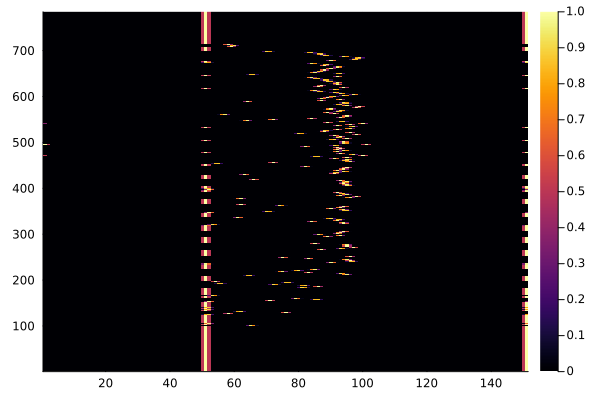

In [21]:
heatmap(islice[:,1,:])

In [22]:
using DiffEqFlux

In [23]:
NeuralODE

NeuralODE

In [24]:
network = Chain(PhasorDense(784 => 128, soft_angle),
                PhasorDense(128 => 10, soft_angle))

Chain(
    layer_1 = PhasorDense(
        layer = Dense(784 => 128, use_bias=false),  # 100_352 parameters
        bias = ComplexBias((128,)),               # 256 parameters
    ),
    layer_2 = PhasorDense(
        layer = Dense(128 => 10, use_bias=false),  # 1_280 parameters
        bias = ComplexBias((10,)),                # 20 parameters
    ),
)         # Total: 101_908 parameters,
          #        plus 0 states.

In [25]:
ps, st = Lux.setup(args.rng, network)

((layer_1 = (layer = (weight = Float32[-0.0056312787 0.04889111 … -0.05050768 0.045184698; -0.040384673 0.033313625 … 0.04332045 -0.045717828; … ; 0.044033002 -0.055932578 … -0.007478507 -0.046164002; 0.024524597 -0.038179252 … 0.0029826495 0.0011508339],), bias = (bias_real = Float32[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], bias_imag = Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])), layer_2 = (layer = (weight = Float32[0.0980228 -0.087151304 … 0.007971453 -0.09662547; -0.023803396 -0.14914384 … 0.017108887 0.012529328; … ; 0.02487466 -0.01981673 … -0.107264556 -0.0035753082; 0.14375904 0.08965352 … -0.13000977 -0.10337137],), bias = (bias_real = Float32[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], bias_imag = Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]))), (layer_1 = (layer = NamedTuple(), bias = NamedTuple(), leakage = Float32[1.0, 1.0, 

In [26]:
du0, _ = network(xt(0.5), ps, st)

(Float32[0.07934533 -0.050931174 … 0.029092008 0.016736083; -0.07364868 0.017480874 … -0.43811715 0.14394987; … ; 0.036655027 -0.48333472 … -0.8182042 -0.53998053; 0.06647279 -0.33643395 … -0.9337917 0.38188273], (layer_1 = (layer = NamedTuple(), bias = NamedTuple()), layer_2 = (layer = NamedTuple(), bias = NamedTuple())))

In [27]:
dudt(u, p, t) = network(xt(t), p, st)[1]

dudt (generic function with 1 method)

In [28]:
u0 = similar(du0) .= 0.0f0

10×128 Matrix{Float32}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [29]:
prob = ODEProblem(dudt, u0, tspan)

ODEProblem with uType Matrix{Float32} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 10.0f0)
u0: 10×128 Matrix{Float32}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [ ]:
dudt(u0, ps, 0.5)

10×128 Matrix{Float32}:
  0.0793453  -0.0509312   0.00396839  …  -0.0585478   0.029092    0.0167361
 -0.0736487   0.0174809  -0.118872       -0.01388    -0.438117    0.14395
  0.0722921   0.0434954   0.049414        0.841079   -0.132157   -0.102793
  0.0414391  -0.0508363  -0.0152622      -0.0696098   0.0227857   0.0573944
 -0.405988    0.606119   -0.0444793       0.0199001  -0.912866   -0.187411
  0.170761    0.0458396  -0.06709     …   0.204713   -0.0208149   0.0100205
 -0.962816    0.0211928  -0.0689323       0.313145    0.948722   -0.0602367
 -0.190936   -0.0336045   0.0194902      -0.039911    0.0421027   0.0583574
  0.036655   -0.483335    0.699563       -0.980373   -0.818204   -0.539981
  0.0664728  -0.336434   -0.0118767      -0.0940952  -0.933792    0.381883

In [30]:
sol = solve(prob, spk_args.solver, spk_args.solver_args...)

MethodError: MethodError: no method matching default_algorithm(::ODEProblem{Matrix{Float32}, Tuple{Float32, Float32}, false, SciMLBase.NullParameters, ODEFunction{false, SciMLBase.AutoSpecialize, typeof(dudt), LinearAlgebra.UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing, Nothing, Nothing}, Base.Pairs{Symbol, Union{}, Tuple{}, @NamedTuple{}}, SciMLBase.StandardODEProblem})
The function `default_algorithm` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  default_algorithm(!Matched::SciMLBase.AbstractBVProblem; kwargs...)
   @ DifferentialEquations ~/.julia/packages/DifferentialEquations/rpSZ8/src/bvp_default_alg.jl:1
  default_algorithm(!Matched::SciMLBase.AbstractNonlinearProblem; kwargs...)
   @ DifferentialEquations ~/.julia/packages/DifferentialEquations/rpSZ8/src/steady_state_default_alg.jl:1
  default_algor